# Support Vector Machines

A support vector machine finds a boundary that separates two classes. In this example, we use two breast cancer features so the boundary can be shown in 2D.

Steps:

1. Load the breast cancer dataset.
2. Use `worst concave points` and `worst perimeter` as the two features.
3. Split the data into train, validation, and test sets.
4. Train linear SVMs with different `C` values.
5. Use the validation set to choose the best `C`.
6. Briefly show a polynomial kernel for comparison.
7. Test the final linear model on the held-out test set.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

RANDOM_STATE = 42

## Load Data

The target labels are:

- `0`: malignant
- `1`: benign

In [2]:
cancer = load_breast_cancer()

X_all = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y_all = pd.Series(cancer.target, name="target")

print(f"Samples: {X_all.shape[0]}")
print(f"Features: {X_all.shape[1]}")
print(dict(enumerate(cancer.target_names)))

X_all.head()

Samples: 569
Features: 30
{0: 'malignant', 1: 'benign'}


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Choose Features

We use two features so the SVM boundary can be plotted in 2D:

- `worst concave points`
- `worst perimeter`

In [3]:
selected_features = ["worst concave points", "worst perimeter"]
X = X_all[selected_features]

X.head()

,worst concave points,worst perimeter
0,0.2654,184.60
1,0.1860,158.80
2,0.2430,152.50
3,0.2575,98.87
4,0.1625,152.20


## Train, Validation, Test Split

We use a 70/15/15 split:

- Train: fit the models.
- Validation: choose the best `C`.
- Test: evaluate the final model once.

In [4]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y_all,
    test_size=0.30,
    stratify=y_all,
    random_state=RANDOM_STATE,
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_STATE,
)

pd.Series({
    "train": len(y_train),
    "validation": len(y_val),
    "test": len(y_test),
}).to_frame("n_samples")

,n_samples
train,398
validation,85
test,86


## Plot The Data

Each point is one tumor sample shown using the two selected features.

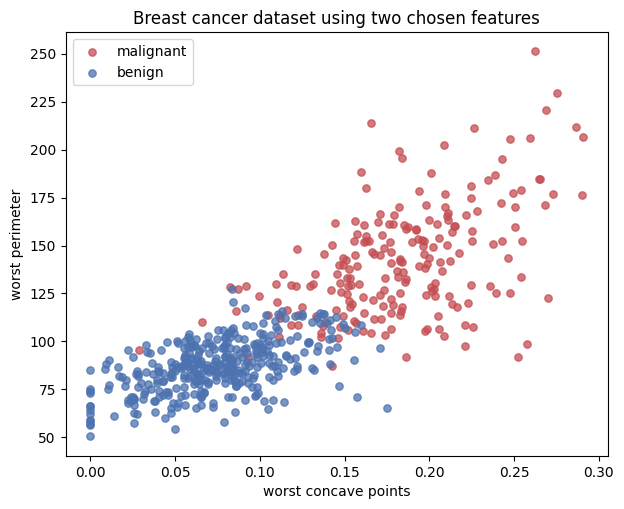

In [5]:
fig, ax = plt.subplots(figsize=(7, 5.5))

ax.scatter(
    X.loc[y_all == 0, selected_features[0]],
    X.loc[y_all == 0, selected_features[1]],
    c="#c44e52",
    s=28,
    alpha=0.75,
    label="malignant",
)
ax.scatter(
    X.loc[y_all == 1, selected_features[0]],
    X.loc[y_all == 1, selected_features[1]],
    c="#4c72b0",
    s=28,
    alpha=0.75,
    label="benign",
)

ax.set_title("Breast cancer dataset using two chosen features")
ax.set_xlabel(selected_features[0])
ax.set_ylabel(selected_features[1])
ax.legend()
plt.show()

## Helper Functions

- `fit_svm()` scales the data and fits the SVM.
- `plot_svm()` draws the boundary, margins, and support vectors.

In [6]:
def fit_svm(X_train, y_train, kernel="linear", C=1, degree=3):
    model = make_pipeline(
        StandardScaler(),
        SVC(kernel=kernel, C=C, degree=degree),
    )
    model.fit(X_train, y_train)
    return model


def plot_svm(model, X_plot, y_plot, title, ax, X_range=None, show_support_vectors=True):
    x_name, y_name = X_plot.columns
    if X_range is None:
        X_range = X_plot

    x_min, x_max = X_range[x_name].min(), X_range[x_name].max()
    y_min, y_max = X_range[y_name].min(), X_range[y_name].max()
    x_pad = (x_max - x_min) * 0.12
    y_pad = (y_max - y_min) * 0.12

    xx, yy = np.meshgrid(
        np.linspace(x_min - x_pad, x_max + x_pad, 300),
        np.linspace(y_min - y_pad, y_max + y_pad, 300),
    )

    grid = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=X_plot.columns)
    scores = model.decision_function(grid).reshape(xx.shape)

    ax.contourf(xx, yy, scores, levels=25, cmap="RdBu", alpha=0.18)
    ax.contour(
        xx,
        yy,
        scores,
        levels=[-1, 0, 1],
        colors=["gray", "black", "gray"],
        linestyles=["--", "-", "--"],
        linewidths=[1, 2, 1],
    )

    ax.scatter(X_plot.loc[y_plot == 0, x_name], X_plot.loc[y_plot == 0, y_name], c="#c44e52", s=28, alpha=0.75, label="malignant")
    ax.scatter(X_plot.loc[y_plot == 1, x_name], X_plot.loc[y_plot == 1, y_name], c="#4c72b0", s=28, alpha=0.75, label="benign")

    if show_support_vectors:
        scaler = model.named_steps["standardscaler"]
        svc = model.named_steps["svc"]
        support_vectors = scaler.inverse_transform(svc.support_vectors_)

        ax.scatter(
            support_vectors[:, 0],
            support_vectors[:, 1],
            s=85,
            facecolors="none",
            edgecolors="black",
            linewidths=1,
            label="support vectors",
        )

    ax.set_title(title)
    ax.set_xlabel(x_name)
    ax.set_ylabel(y_name)

## C Parameter

Each linear SVM is trained on the training set and scored on the validation set.

`C` controls how strict the margin is:

- Smaller `C`: wider margin, more tolerance for points inside the margin.
- Larger `C`: stricter fit, less tolerance for margin violations.

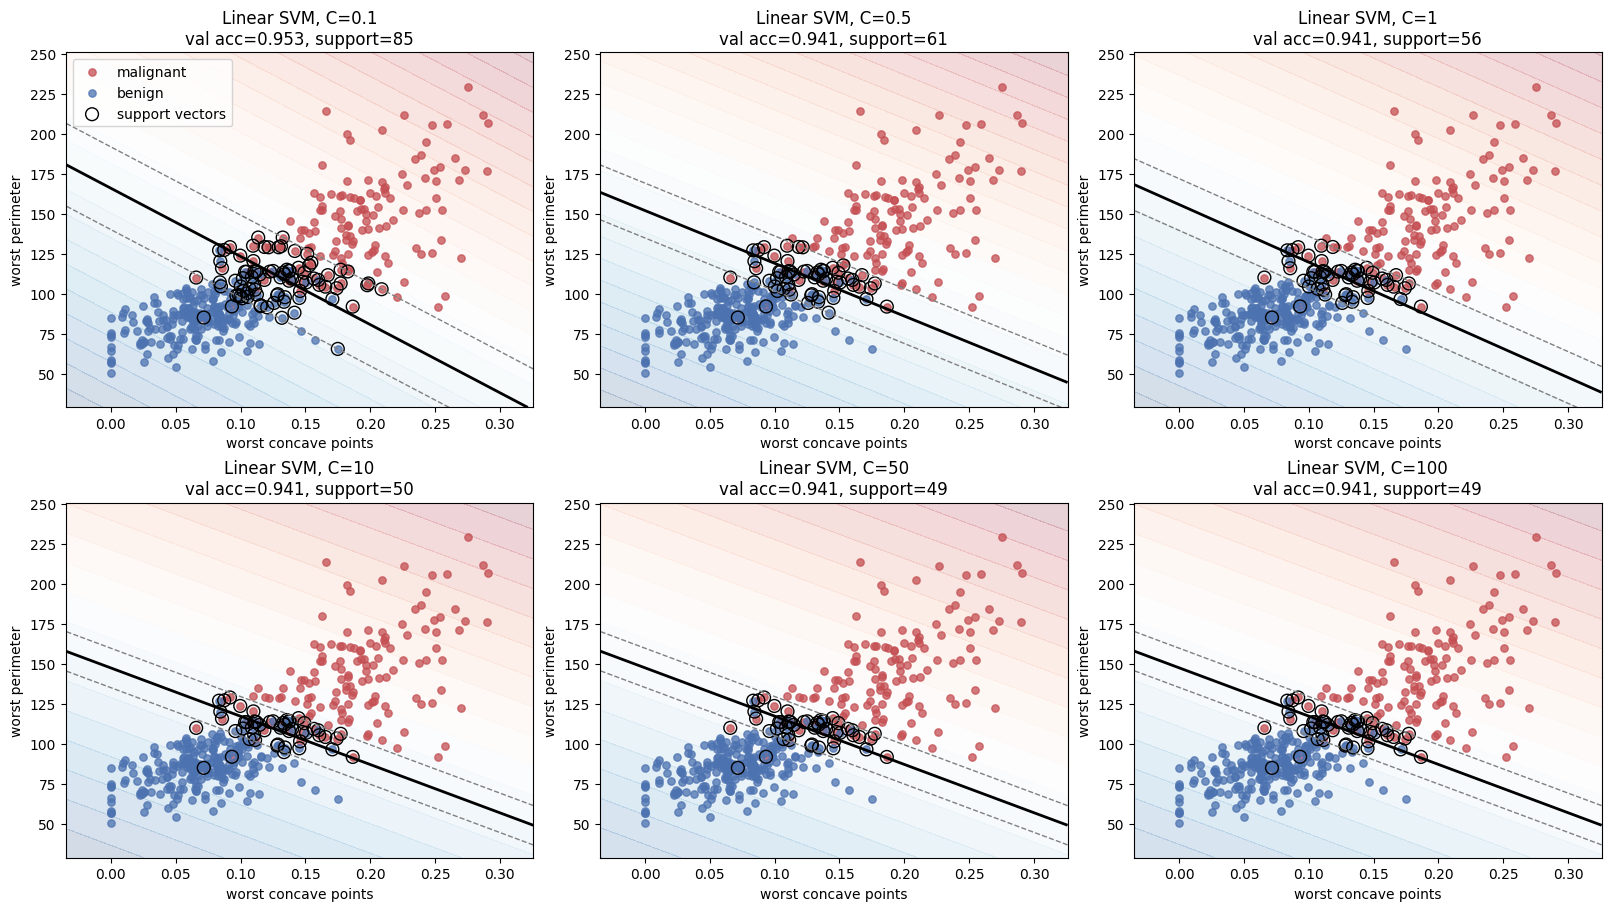

,kernel,C,validation_accuracy,support_vectors
0,linear,0.1,0.952941,85
1,linear,0.5,0.941176,61
2,linear,1.0,0.941176,56
3,linear,10.0,0.941176,50
4,linear,50.0,0.941176,49
5,linear,100.0,0.941176,49


In [7]:
C_values = [0.1, 0.5, 1, 10, 50, 100]
C_results = []

fig, axes = plt.subplots(2, 3, figsize=(16, 9), constrained_layout=True)

for C, ax in zip(C_values, axes.ravel()):
    model = fit_svm(X_train, y_train, kernel="linear", C=C)
    val_accuracy = accuracy_score(y_val, model.predict(X_val))
    n_support = model.named_steps["svc"].support_vectors_.shape[0]

    C_results.append({
        "kernel": "linear",
        "C": C,
        "validation_accuracy": val_accuracy,
        "support_vectors": n_support,
    })

    title = f"Linear SVM, C={C}\nval acc={val_accuracy:.3f}, support={n_support}"
    plot_svm(model, X_train, y_train, title, ax)

axes.ravel()[0].legend(loc="best")
plt.show()

pd.DataFrame(C_results)

## Kernel

The final model will stay linear. This polynomial kernel plot is only included to show how a kernel can make the boundary curved.

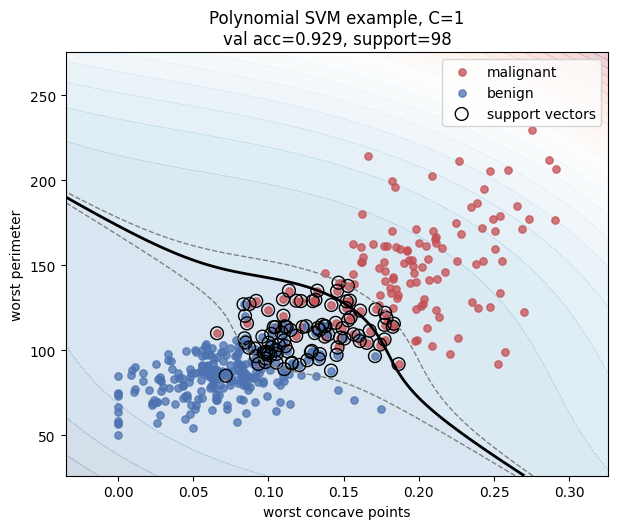

In [8]:
poly_model = fit_svm(X_train, y_train, kernel="poly", C=1, degree=3)
poly_val_accuracy = accuracy_score(y_val, poly_model.predict(X_val))
poly_support = poly_model.named_steps["svc"].support_vectors_.shape[0]

fig, ax = plt.subplots(figsize=(7, 5.5))
plot_svm(
    poly_model,
    X_train,
    y_train,
    f"Polynomial SVM example, C=1\nval acc={poly_val_accuracy:.3f}, support={poly_support}",
    ax,
    X_range=X,
)
ax.legend(loc="best")
plt.show()

## Choose The Best Linear Model

We choose the best linear SVM using validation accuracy. The only setting being tuned is `C`.

In [9]:
linear_results = []

for C in [0.1, 0.5, 1, 10, 50, 100]:
    model = fit_svm(X_train, y_train, kernel="linear", C=C)
    linear_results.append({
        "kernel": "linear",
        "C": C,
        "train_accuracy": accuracy_score(y_train, model.predict(X_train)),
        "validation_accuracy": accuracy_score(y_val, model.predict(X_val)),
        "support_vectors": model.named_steps["svc"].support_vectors_.shape[0],
    })

results = (
    pd.DataFrame(linear_results)
    .sort_values(["validation_accuracy", "train_accuracy"], ascending=False)
    .reset_index(drop=True)
)

results

,kernel,C,train_accuracy,validation_accuracy,support_vectors
0,linear,0.1,0.949749,0.952941,85
1,linear,10.0,0.952261,0.941176,50
2,linear,0.5,0.949749,0.941176,61
3,linear,1.0,0.949749,0.941176,56
4,linear,50.0,0.949749,0.941176,49
5,linear,100.0,0.949749,0.941176,49


## Final Test

After choosing the best linear `C`, we retrain using `train + validation` and report test accuracy.

In [10]:
best_settings = {
    "kernel": "linear",
    "C": float(results.iloc[0]["C"]),
}

print("Best validation settings:", best_settings)

X_train_val = pd.concat([X_train, X_val])
y_train_val = pd.concat([y_train, y_val])

final_model = fit_svm(X_train_val, y_train_val, **best_settings)
test_predictions = final_model.predict(X_test)

test_accuracy = accuracy_score(y_test, test_predictions)
print(f"Test accuracy: {test_accuracy:.3f}")

Best validation settings: {'kernel': 'linear', 'C': 0.1}
Test accuracy: 0.872


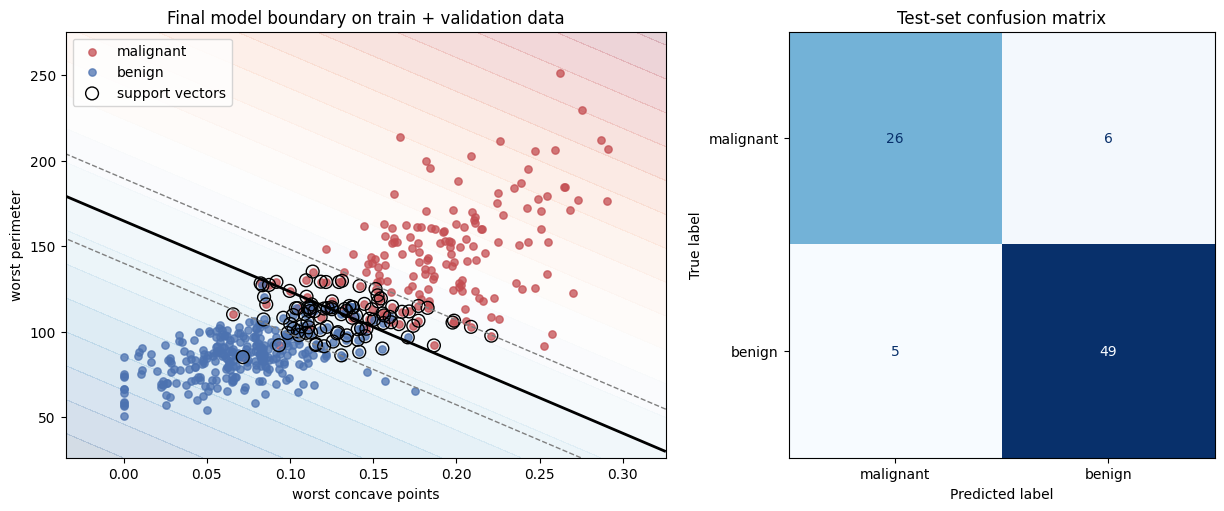

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

plot_svm(
    final_model,
    X_train_val,
    y_train_val,
    "Final model boundary on train + validation data",
    axes[0],
    X_range=X,
)
axes[0].legend(loc="best")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_predictions,
    display_labels=cancer.target_names,
    cmap="Blues",
    colorbar=False,
    ax=axes[1],
)
axes[1].set_title("Test-set confusion matrix")
plt.show()

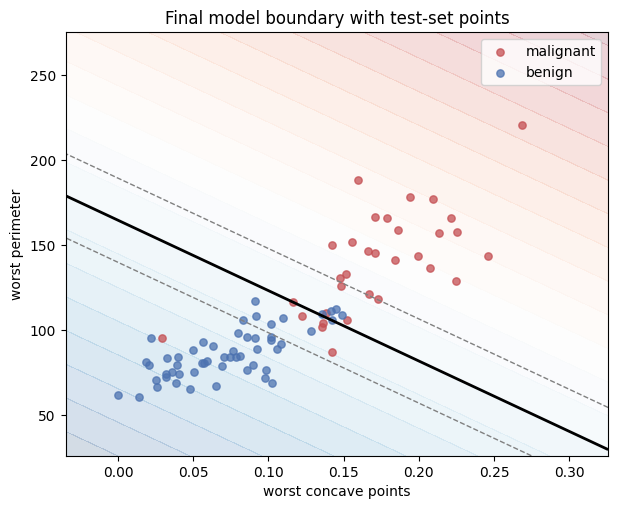

In [12]:
fig, ax = plt.subplots(figsize=(7, 5.5))

plot_svm(
    final_model,
    X_test,
    y_test,
    "Final model boundary with test-set points",
    ax,
    X_range=X,
    show_support_vectors=False,
)

ax.legend(loc="best")
plt.show()